In [22]:
from pathlib import Path
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point

SP_DIR = Path("/leonardo_scratch/fast/ICT26_ESP/ntilinin/access-om2/archive/1deg_speedy_ryf-cosima100yr")
JR_DIR = Path("/leonardo_scratch/fast/ICT26_ESP/ntilinin/access-om2/archive/1deg_jra55_ryf_100yr")

SP_FILES = sorted(SP_DIR.glob("output*/ocean/ocean-2d-surface_pot_temp-1-monthly-mean-ym_*.nc"))
JR_FILES = sorted(JR_DIR.glob("output*/ocean/ocean-2d-surface_pot_temp-1-monthly-mean-ym_*.nc"))

print("SPEEDY files:", len(SP_FILES))
print("JRA files:", len(JR_FILES))
print("SP first/last:", SP_FILES[0], SP_FILES[-1])
print("JR first/last:", JR_FILES[0], JR_FILES[-1])

SPEEDY files: 100
JRA files: 95
SP first/last: /leonardo_scratch/fast/ICT26_ESP/ntilinin/access-om2/archive/1deg_speedy_ryf-cosima100yr/output000/ocean/ocean-2d-surface_pot_temp-1-monthly-mean-ym_1900_01.nc /leonardo_scratch/fast/ICT26_ESP/ntilinin/access-om2/archive/1deg_speedy_ryf-cosima100yr/output019/ocean/ocean-2d-surface_pot_temp-1-monthly-mean-ym_1999_01.nc
JR first/last: /leonardo_scratch/fast/ICT26_ESP/ntilinin/access-om2/archive/1deg_jra55_ryf_100yr/output000/ocean/ocean-2d-surface_pot_temp-1-monthly-mean-ym_1900_01.nc /leonardo_scratch/fast/ICT26_ESP/ntilinin/access-om2/archive/1deg_jra55_ryf_100yr/output018/ocean/ocean-2d-surface_pot_temp-1-monthly-mean-ym_1994_01.nc


In [23]:
sst_sp = xr.open_mfdataset(
    SP_FILES,
    combine="by_coords",
    parallel=False
)["surface_pot_temp"]

sst_jr = xr.open_mfdataset(
    JR_FILES,
    combine="by_coords",
    parallel=False
)["surface_pot_temp"]

print("SPEEDY:", sst_sp.time.min().values, sst_sp.time.max().values, sst_sp.sizes["time"])
print("JRA:", sst_jr.time.min().values, sst_jr.time.max().values, sst_jr.sizes["time"])

SPEEDY: 1900-01-16 12:00:00 1999-12-16 12:00:00 1200
JRA: 1900-01-16 12:00:00 1994-12-16 12:00:00 1140


In [24]:
sp_y0 = int(str(sst_sp.time.values[0])[:4])
sp_y1 = int(str(sst_sp.time.values[-1])[:4])
jr_y0 = int(str(sst_jr.time.values[0])[:4])
jr_y1 = int(str(sst_jr.time.values[-1])[:4])

end_year = min(sp_y1, jr_y1)
start_year = end_year - 29

print("Using period:", start_year, end_year)

Using period: 1965 1994


In [25]:
sst_map_sp = sst_sp.sel(
    time=slice(f"{start_year}-01-01", f"{end_year}-12-31")
).mean("time", skipna=True).compute()

print("SPEEDY mean done")

sst_map_jr = sst_jr.sel(
    time=slice(f"{start_year}-01-01", f"{end_year}-12-31")
).mean("time", skipna=True).compute()

print("JRA mean done")

SPEEDY mean done
JRA mean done


In [26]:
sst_map_sp = sst_map_sp - 273.15
sst_map_jr = sst_map_jr - 273.15
sst_diff = sst_map_sp - sst_map_jr

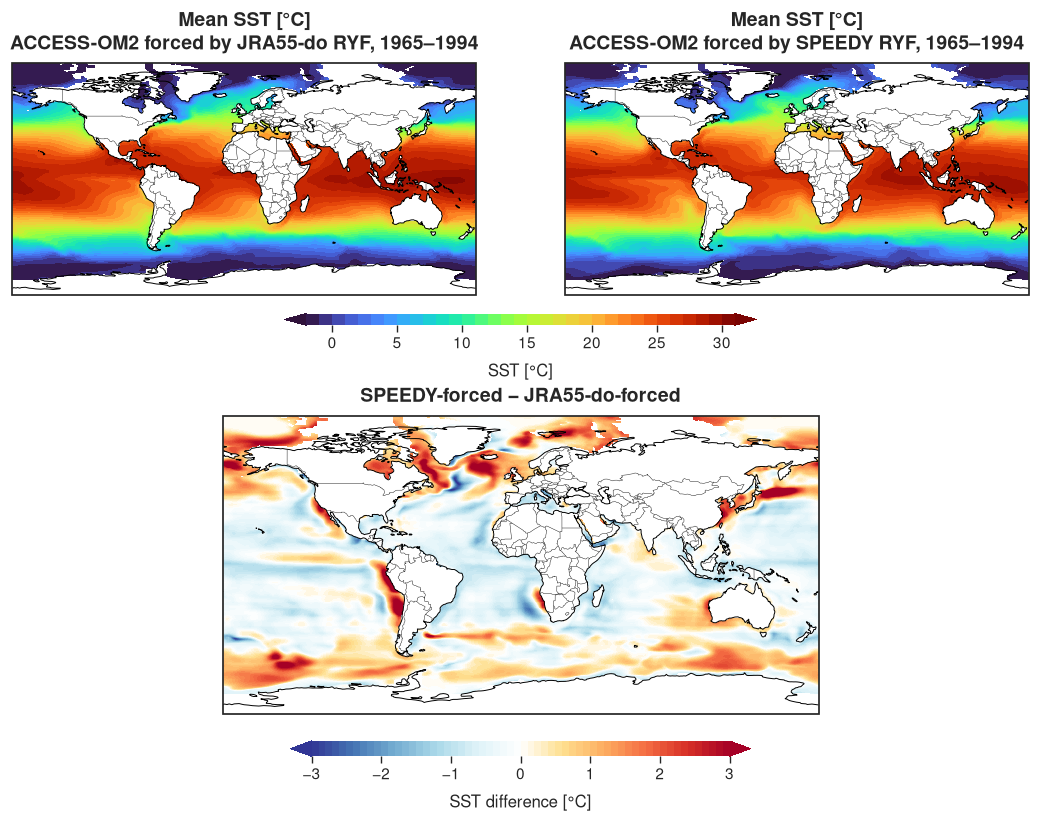

In [29]:
sns.set_theme(style="white")
plt.rcParams.update({"font.family":"Nimbus Sans"})

sst_cmap=plt.get_cmap("turbo")

diff_cmap=LinearSegmentedColormap.from_list(
    "SSTBlueWhiteRed",
    ["#313695","#4575b4","#74add1","#abd9e9","#e0f3f8","#ffffff",
     "#fee090","#fdae61","#f46d43","#d73027","#a50026"],
    N=256
)

sst_levels=np.arange(-2,32,1)
sst_ticks=np.arange(0,31,5)

diff_levels=np.arange(-3,3.1,0.1)
diff_norm=mcolors.TwoSlopeNorm(vmin=-3,vcenter=0,vmax=3)
diff_ticks=np.arange(-3,4,1)

def make_cyclic(da):
    data,lon=add_cyclic_point(da.values,coord=da.xt_ocean.values,axis=da.get_axis_num("xt_ocean"))
    return data,lon

def setup_map(ax):
    ax.set_global()
    ax.coastlines(resolution="110m",linewidth=0.7)
    ax.add_feature(cfeature.BORDERS,linewidth=0.3)

fig=plt.figure(figsize=(14,9),facecolor="white")
gs=fig.add_gridspec(2,6,height_ratios=[1,1.3],hspace=0.3,wspace=0.12)

ax1=fig.add_subplot(gs[0,0:3],projection=ccrs.PlateCarree())
ax2=fig.add_subplot(gs[0,3:6],projection=ccrs.PlateCarree())
ax3=fig.add_subplot(gs[1,0:6],projection=ccrs.PlateCarree())

# ACCESS-OM2 forced by JRA55-do
data,lon=make_cyclic(sst_map_jr)
im1=ax1.contourf(lon,sst_map_jr.yt_ocean.values,data,levels=sst_levels,cmap=sst_cmap,transform=ccrs.PlateCarree(),extend="both")
setup_map(ax1)
ax1.set_title(f"Mean SST [°C]\nACCESS-OM2 forced by JRA55-do RYF, {start_year}–{end_year}",
              fontsize=14,fontweight="bold",pad=10)

# ACCESS-OM2 forced by SPEEDY
data,lon=make_cyclic(sst_map_sp)
im2=ax2.contourf(lon,sst_map_sp.yt_ocean.values,data,levels=sst_levels,cmap=sst_cmap,transform=ccrs.PlateCarree(),extend="both")
setup_map(ax2)
ax2.set_title(f"Mean SST [°C]\nACCESS-OM2 forced by SPEEDY RYF, {start_year}–{end_year}",
              fontsize=14,fontweight="bold",pad=10)

# Difference
data,lon=make_cyclic(sst_diff)
im3=ax3.contourf(lon,sst_diff.yt_ocean.values,data,levels=diff_levels,norm=diff_norm,cmap=diff_cmap,transform=ccrs.PlateCarree(),extend="both")
setup_map(ax3)
ax3.set_title("SPEEDY-forced − JRA55-do-forced",
              fontsize=14,fontweight="bold",pad=10)

cbar1=fig.colorbar(im1,ax=[ax1,ax2],orientation="horizontal",fraction=0.045,pad=0.07,aspect=40,ticks=sst_ticks)
cbar1.set_label("SST [°C]",fontsize=12,labelpad=8)
cbar1.ax.tick_params(labelsize=11,length=5,width=1)
cbar1.outline.set_visible(False)

cbar2=fig.colorbar(im3,ax=ax3,orientation="horizontal",fraction=0.045,pad=0.08,aspect=30,ticks=diff_ticks)
cbar2.set_label("SST difference [°C]",fontsize=12,labelpad=8)
cbar2.ax.tick_params(labelsize=11,length=5,width=1)
cbar2.outline.set_visible(False)

fig.savefig(
    f"figures/accessom2_mean_sst_speedy_forced_vs_jra55do_forced_{start_year}_{end_year}.png",
    dpi=150,bbox_inches="tight"
)

plt.show()

In [30]:
SP_FILES = sorted(SP_DIR.glob("output*/ocean/ocean-2d-net_sfc_heating-1-monthly-mean-ym_*.nc"))
JR_FILES = sorted(JR_DIR.glob("output*/ocean/ocean-2d-net_sfc_heating-1-monthly-mean-ym_*.nc"))

print("SPEEDY files:", len(SP_FILES))
print("JRA files:", len(JR_FILES))
print("SP first/last:", SP_FILES[0], SP_FILES[-1])
print("JR first/last:", JR_FILES[0], JR_FILES[-1])

SPEEDY files: 100
JRA files: 95
SP first/last: /leonardo_scratch/fast/ICT26_ESP/ntilinin/access-om2/archive/1deg_speedy_ryf-cosima100yr/output000/ocean/ocean-2d-net_sfc_heating-1-monthly-mean-ym_1900_01.nc /leonardo_scratch/fast/ICT26_ESP/ntilinin/access-om2/archive/1deg_speedy_ryf-cosima100yr/output019/ocean/ocean-2d-net_sfc_heating-1-monthly-mean-ym_1999_01.nc
JR first/last: /leonardo_scratch/fast/ICT26_ESP/ntilinin/access-om2/archive/1deg_jra55_ryf_100yr/output000/ocean/ocean-2d-net_sfc_heating-1-monthly-mean-ym_1900_01.nc /leonardo_scratch/fast/ICT26_ESP/ntilinin/access-om2/archive/1deg_jra55_ryf_100yr/output018/ocean/ocean-2d-net_sfc_heating-1-monthly-mean-ym_1994_01.nc


In [31]:
q_sp = xr.open_mfdataset(
    SP_FILES,
    combine="by_coords",
    parallel=False
)["net_sfc_heating"]

q_jr = xr.open_mfdataset(
    JR_FILES,
    combine="by_coords",
    parallel=False
)["net_sfc_heating"]

print("SPEEDY:", q_sp.time.min().values, q_sp.time.max().values, q_sp.sizes["time"])
print("JRA:", q_jr.time.min().values, q_jr.time.max().values, q_jr.sizes["time"])

SPEEDY: 1900-01-16 12:00:00 1999-12-16 12:00:00 1200
JRA: 1900-01-16 12:00:00 1994-12-16 12:00:00 1140


In [32]:
q_map_sp = q_sp.sel(
    time=slice(f"{start_year}-01-01", f"{end_year}-12-31")
).mean("time", skipna=True).compute()

print("SPEEDY heating mean done")

q_map_jr = q_jr.sel(
    time=slice(f"{start_year}-01-01", f"{end_year}-12-31")
).mean("time", skipna=True).compute()

print("JRA heating mean done")

q_diff = q_map_sp - q_map_jr

SPEEDY heating mean done
JRA heating mean done


In [33]:
q_map_sp = q_sp.sel(
    time=slice(f"{start_year}-01-01", f"{end_year}-12-31")
).mean("time", skipna=True).compute()

print("SPEEDY heating mean done")

q_map_jr = q_jr.sel(
    time=slice(f"{start_year}-01-01", f"{end_year}-12-31")
).mean("time", skipna=True).compute()

print("JRA heating mean done")

q_diff = q_map_sp - q_map_jr

SPEEDY heating mean done
JRA heating mean done


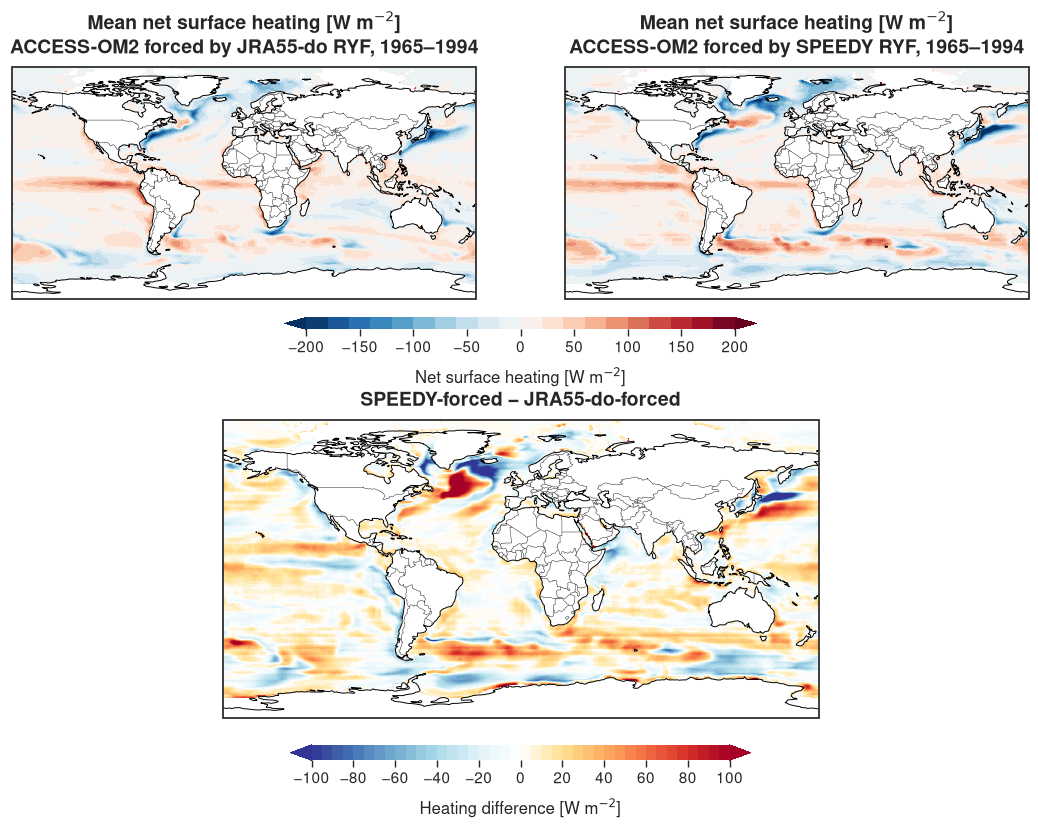

In [35]:
sns.set_theme(style="white")
plt.rcParams.update({"font.family":"Nimbus Sans"})

heat_cmap = plt.get_cmap("RdBu_r")

diff_cmap = LinearSegmentedColormap.from_list(
    "HeatBlueWhiteRed",
    ["#313695","#4575b4","#74add1","#abd9e9","#e0f3f8","#ffffff",
     "#fee090","#fdae61","#f46d43","#d73027","#a50026"],
    N=256
)

heat_levels = np.arange(-200, 220, 20)
heat_norm = mcolors.TwoSlopeNorm(vmin=-200, vcenter=0, vmax=200)
heat_ticks = np.arange(-200, 201, 50)

diff_levels = np.arange(-100, 105, 5)
diff_norm = mcolors.TwoSlopeNorm(vmin=-100, vcenter=0, vmax=100)
diff_ticks = np.arange(-100, 101, 20)

def make_cyclic(da):
    data,lon = add_cyclic_point(
        da.values, coord=da.xt_ocean.values,
        axis=da.get_axis_num("xt_ocean")
    )
    return data,lon

def setup_map(ax):
    ax.set_global()
    ax.coastlines(resolution="110m", linewidth=0.7)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)

fig = plt.figure(figsize=(14,9), facecolor="white")
gs = fig.add_gridspec(2,6,height_ratios=[1,1.3],hspace=0.3,wspace=0.12)

ax1 = fig.add_subplot(gs[0,0:3], projection=ccrs.PlateCarree())
ax2 = fig.add_subplot(gs[0,3:6], projection=ccrs.PlateCarree())
ax3 = fig.add_subplot(gs[1,0:6], projection=ccrs.PlateCarree())

data,lon = make_cyclic(q_map_jr)
im1 = ax1.contourf(
    lon,q_map_jr.yt_ocean.values,data,
    levels=heat_levels,norm=heat_norm,cmap=heat_cmap,
    transform=ccrs.PlateCarree(),extend="both"
)
setup_map(ax1)
ax1.set_title(
    f"Mean net surface heating [W m$^{{-2}}$]\nACCESS-OM2 forced by JRA55-do RYF, {start_year}–{end_year}",
    fontsize=14,fontweight="bold",pad=10
)

data,lon = make_cyclic(q_map_sp)
im2 = ax2.contourf(
    lon,q_map_sp.yt_ocean.values,data,
    levels=heat_levels,norm=heat_norm,cmap=heat_cmap,
    transform=ccrs.PlateCarree(),extend="both"
)
setup_map(ax2)
ax2.set_title(
    f"Mean net surface heating [W m$^{{-2}}$]\nACCESS-OM2 forced by SPEEDY RYF, {start_year}–{end_year}",
    fontsize=14,fontweight="bold",pad=10
)

data,lon = make_cyclic(q_diff)
im3 = ax3.contourf(
    lon,q_diff.yt_ocean.values,data,
    levels=diff_levels,norm=diff_norm,cmap=diff_cmap,
    transform=ccrs.PlateCarree(),extend="both"
)
setup_map(ax3)
ax3.set_title(
    "SPEEDY-forced − JRA55-do-forced",
    fontsize=14,fontweight="bold",pad=10
)

cbar1 = fig.colorbar(
    im1,ax=[ax1,ax2],orientation="horizontal",
    fraction=0.045,pad=0.07,aspect=40,ticks=heat_ticks
)
cbar1.set_label("Net surface heating [W m$^{-2}$]",fontsize=12,labelpad=8)
cbar1.ax.tick_params(labelsize=11,length=5,width=1)
cbar1.outline.set_visible(False)

cbar2 = fig.colorbar(
    im3,ax=ax3,orientation="horizontal",
    fraction=0.045,pad=0.08,aspect=30,ticks=diff_ticks
)
cbar2.set_label("Heating difference [W m$^{-2}$]",fontsize=12,labelpad=8)
cbar2.ax.tick_params(labelsize=11,length=5,width=1)
cbar2.outline.set_visible(False)

fig.savefig(
    f"figures/accessom2_mean_net_surface_heating_speedy_forced_vs_jra55do_forced_{start_year}_{end_year}.png",
    dpi=150,bbox_inches="tight"
)

plt.show()

In [36]:
SP_FILES = sorted(SP_DIR.glob("output*/ocean/ocean-2d-surface_salt-1-monthly-mean-ym_*.nc"))
JR_FILES = sorted(JR_DIR.glob("output*/ocean/ocean-2d-surface_salt-1-monthly-mean-ym_*.nc"))

SPEEDY files: 100
JRA files: 95
SP first/last: /leonardo_scratch/fast/ICT26_ESP/ntilinin/access-om2/archive/1deg_speedy_ryf-cosima100yr/output000/ocean/ocean-2d-surface_salt-1-monthly-mean-ym_1900_01.nc /leonardo_scratch/fast/ICT26_ESP/ntilinin/access-om2/archive/1deg_speedy_ryf-cosima100yr/output019/ocean/ocean-2d-surface_salt-1-monthly-mean-ym_1999_01.nc
JR first/last: /leonardo_scratch/fast/ICT26_ESP/ntilinin/access-om2/archive/1deg_jra55_ryf_100yr/output000/ocean/ocean-2d-surface_salt-1-monthly-mean-ym_1900_01.nc /leonardo_scratch/fast/ICT26_ESP/ntilinin/access-om2/archive/1deg_jra55_ryf_100yr/output018/ocean/ocean-2d-surface_salt-1-monthly-mean-ym_1994_01.nc


In [37]:
sss_sp = xr.open_mfdataset(
    SP_FILES,
    combine="by_coords",
    parallel=False
)["surface_salt"]

sss_jr = xr.open_mfdataset(
    JR_FILES,
    combine="by_coords",
    parallel=False
)["surface_salt"]

print("SPEEDY:", sss_sp.time.min().values, sss_sp.time.max().values, sss_sp.sizes["time"])
print("JRA:", sss_jr.time.min().values, sss_jr.time.max().values, sss_jr.sizes["time"])
print(sss_sp.attrs)

SPEEDY: 1900-01-16 12:00:00 1999-12-16 12:00:00 1200
JRA: 1900-01-16 12:00:00 1994-12-16 12:00:00 1140
{'long_name': 'Practical Salinity', 'units': 'psu', 'valid_range': array([-10., 100.], dtype=float32), 'cell_methods': 'time: mean', 'time_avg_info': 'average_T1,average_T2,average_DT', 'standard_name': 'sea_surface_salinity'}


In [38]:
sss_map_sp = sss_sp.sel(
    time=slice(f"{start_year}-01-01", f"{end_year}-12-31")
).mean("time", skipna=True).compute()

print("SPEEDY salinity mean done")

sss_map_jr = sss_jr.sel(
    time=slice(f"{start_year}-01-01", f"{end_year}-12-31")
).mean("time", skipna=True).compute()

print("JRA salinity mean done")

sss_diff = sss_map_sp - sss_map_jr

SPEEDY salinity mean done
JRA salinity mean done


In [ ]:
sns.set_theme(style="white")
plt.rcParams.update({"font.family":"Nimbus Sans"})

sss_cmap = plt.get_cmap("turbo")

diff_cmap = LinearSegmentedColormap.from_list(
    "SSSBlueWhiteRed",
    ["#313695","#4575b4","#74add1","#abd9e9","#e0f3f8","#ffffff",
     "#fee090","#fdae61","#f46d43","#d73027","#a50026"],
    N=256
)

sss_levels = np.arange(30, 38.25, 0.25)
sss_ticks = np.arange(30, 39, 1)

diff_levels = np.arange(-2, 2.1, 0.1)
diff_norm = mcolors.TwoSlopeNorm(vmin=-2, vcenter=0, vmax=2)
diff_ticks = np.arange(-2, 2.5, 0.5)

fig = plt.figure(figsize=(14,9), facecolor="white")
gs = fig.add_gridspec(2,6,height_ratios=[1,1.3],hspace=0.3,wspace=0.12)

ax1 = fig.add_subplot(gs[0,0:3], projection=ccrs.PlateCarree())
ax2 = fig.add_subplot(gs[0,3:6], projection=ccrs.PlateCarree())
ax3 = fig.add_subplot(gs[1,0:6], projection=ccrs.PlateCarree())

data,lon = make_cyclic(sss_map_jr)
im1 = ax1.contourf(
    lon,sss_map_jr.yt_ocean.values,data,
    levels=sss_levels,cmap=sss_cmap,
    transform=ccrs.PlateCarree(),extend="both"
)
setup_map(ax1)
ax1.set_title(
    f"Mean SSS [psu]\nACCESS-OM2 forced by JRA55-do RYF, {start_year}–{end_year}",
    fontsize=14,fontweight="bold",pad=10
)

data,lon = make_cyclic(sss_map_sp)
im2 = ax2.contourf(
    lon,sss_map_sp.yt_ocean.values,data,
    levels=sss_levels,cmap=sss_cmap,
    transform=ccrs.PlateCarree(),extend="both"
)
setup_map(ax2)
ax2.set_title(
    f"Mean SSS [psu]\nACCESS-OM2 forced by SPEEDY RYF, {start_year}–{end_year}",
    fontsize=14,fontweight="bold",pad=10
)

data,lon = make_cyclic(sss_diff)
im3 = ax3.contourf(
    lon,sss_diff.yt_ocean.values,data,
    levels=diff_levels,norm=diff_norm,cmap=diff_cmap,
    transform=ccrs.PlateCarree(),extend="both"
)
setup_map(ax3)
ax3.set_title(
    "SPEEDY-forced − JRA55-do-forced",
    fontsize=14,fontweight="bold",pad=10
)

cbar1 = fig.colorbar(
    im1,ax=[ax1,ax2],orientation="horizontal",
    fraction=0.045,pad=0.07,aspect=40,ticks=sss_ticks
)
cbar1.set_label("Sea surface salinity [psu]",fontsize=12,labelpad=8)
cbar1.ax.tick_params(labelsize=11,length=5,width=1)
cbar1.outline.set_visible(False)

cbar2 = fig.colorbar(
    im3,ax=ax3,orientation="horizontal",
    fraction=0.045,pad=0.08,aspect=30,ticks=diff_ticks
)
cbar2.set_label("SSS difference [psu]",fontsize=12,labelpad=8)
cbar2.ax.tick_params(labelsize=11,length=5,width=1)
cbar2.outline.set_visible(False)

fig.savefig(
    f"figures/accessom2_mean_sss_speedy_forced_vs_jra55do_forced_{start_year}_{end_year}.png",
    dpi=150,bbox_inches="tight"
)

plt.show()